In [198]:
# =============
# IMPORT REPO
# =============

# Install missing packages
!pip install boto3 metloom rasterio numpy pandas
!pip install scikit-learn tqdm joblib
!pip install matplotlib seaborn

import os
import importlib.util
import pandas as pd
from pathlib import Path


# For metloom (may need additional dependencies)
!pip install folium geopy requests-cache

def import_repo(repo_path='../..'):
    """
    Import all Python files from a repository
    """
    repo_path = Path(repo_path).resolve()
    print(f"Importing repository from: {repo_path}")
    
    modules = {}
    
    # Walk through all directories
    for root, dirs, files in os.walk(repo_path):
        # Skip hidden directories like .git, __pycache__
        dirs[:] = [d for d in dirs if not d.startswith('.') and d != '__pycache__']
        
        for file in files:
            if file.endswith('.py') and not file.startswith('__'):
                file_path = os.path.join(root, file)
                rel_path = os.path.relpath(file_path, repo_path)
                
                # Create a valid module name
                module_name = rel_path.replace(os.sep, '_').replace('.py', '')
                module_name = ''.join(c for c in module_name if c.isalnum() or c == '_')
                
                try:
                    #Import the module
                    spec = importlib.util.spec_from_file_location(module_name, file_path)
                    module = importlib.util.module_from_spec(spec)
                    spec.loader.exec_module(module)
                    
                    modules[rel_path] = module
                    print(f"✅ Imported: {rel_path} as {module_name}")
                    
                except Exception as e:
                    print(f" Failed to import {rel_path}: {e}")
    
    print(f"\n Total modules imported: {len(modules)}")
    return modules

# Import the entire repo
repo_modules = import_repo('../..')  # Use '.' for current directory

Importing repository from: /Users/samharris/CSCI-5240-Project
 Failed to import lambda/cron-job/update_weather_data.py: No module named 'utils.s3_helpers'
 Failed to import lambda/cron-job/update_caic_data.py: No module named 'utils.s3_helpers'
 Failed to import lambda/cron-job/lambda_function.py: No module named 'update_caic_data'
✅ Imported: lambda/cron-job/utils/process_caic.py as lambda_cronjob_utils_process_caic
✅ Imported: lambda/cron-job/utils/weather_utils.py as lambda_cronjob_utils_weather_utils
 Failed to import lambda/cron-job/utils/s3_helpers.py: No module named 'dotenv'
Bounds: {'south': 37.0, 'north': 41.0, 'west': -109.1, 'east': -102.0}
This may take 10-30 minutes depending on connection...

✗ Download failed: 401 Client Error: 401 for url: https://portal.opentopography.org/API/globaldem?demtype=SRTMGL3&south=37.0&north=41.0&west=-109.1&east=-102.0&outputFormat=GTiff&API_Key=api_key_here

Alternative: Download manually from OpenTopography:
https://portal.opentopography.

AVALANCHE PREDICTION PIPELINE

LOCATING REPOSITORY...
Current directory: /Users/samharris/CSCI-5240-Project/ai-model/training
Repository root: /Users/samharris/CSCI-5240-Project
✅ Loaded training file: training_data.csv with shape: (28623, 21)

TRAINING DATA EXAMINATION
Training data shape: (28623, 22)

First 3 rows:
                        Observation ID                       Date  Longitude  \
0                           NEG_003200  2016-10-02 07:00:00+00:00  -107.1176   
1  -107.054760_38.883379_20250116_1900  2025-01-16 19:00:00+00:00  -107.0548   
2  -106.381128_38.622235_20260127_1900  2026-01-27 19:00:00+00:00  -106.3811   

   latitude      Area Aspect Type Trigger  avalanche_size  avalanche_occurred  \
0   39.2007     Aspen    NaN  NaN     NaN             0.0                   0   
1   38.8834  Gunnison      E    L       N             1.0                   1   
2   38.6222   Sawatch      E   HS       N             1.5                   1   

   ...  aspect_degrees  aspect_card

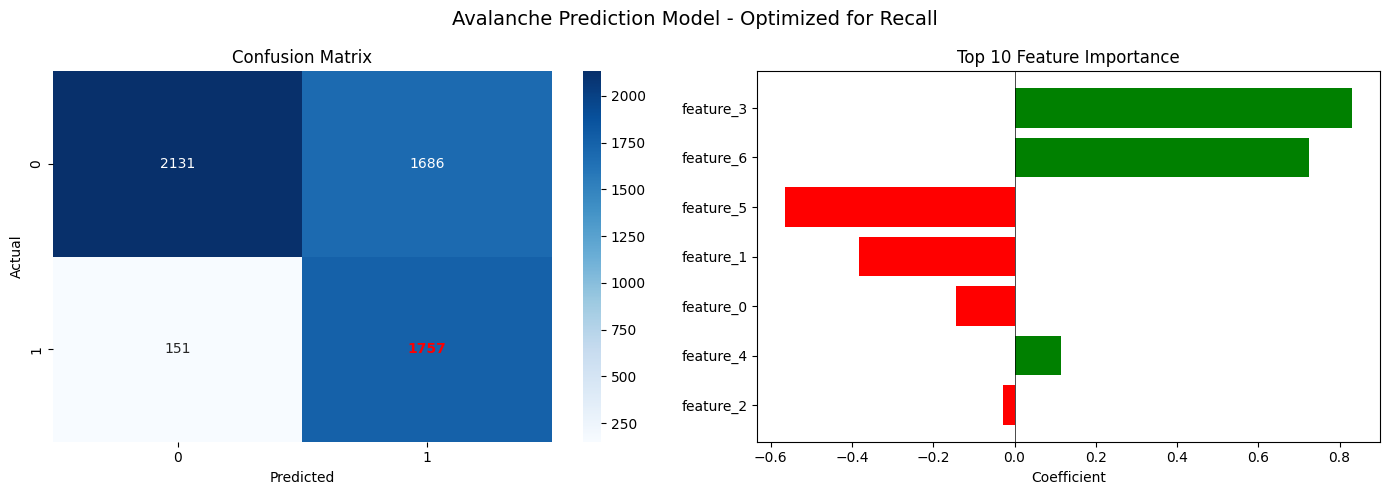

✅ Visualization saved as 'avalanche_model_results.png'

SAVING MODEL
✅ Model saved to /Users/samharris/CSCI-5240-Project/models/avalanche_model.pkl


In [ ]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer, recall_score
import warnings
warnings.filterwarnings('ignore')

# ============================================
# PATHS & DATA LOADING
# ============================================
repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))

data_processed_dir = repo_root / 'data' / 'processed'
csv_files = list(data_processed_dir.glob('*train*.csv')) + list(data_processed_dir.glob('*training*.csv'))
if csv_files:
    training_data = pd.read_csv(csv_files[0])
else:
    csv_files = list(data_processed_dir.glob('*.csv'))
    training_data = pd.read_csv(max(csv_files, key=lambda x: x.stat().st_mtime))

# ============================================
# FEATURE ENGINEERING
# ============================================
target_col = 'avalanche_occurred'
feature_cols = [col for col in training_data.columns if col != target_col]
X = training_data[feature_cols].copy()

# Snow ratio
snow_ratio = np.zeros(len(X))
both_non_zero = ~((X['snow_depth'] == 0) | X['snow_depth'].isnull() |
                   (X['swe'] == 0) | X['swe'].isnull())
snow_ratio[both_non_zero] = X.loc[both_non_zero, 'snow_depth'] / X.loc[both_non_zero, 'swe']
training_data['snow_ratio'] = snow_ratio

# Aspect: distance from south
training_data['aspect_degrees'] = abs(180 - training_data['aspect_degrees'])

# ============================================
# PREPARE X, y
# ============================================
feature_cols = [col for col in training_data.columns if col != target_col]
X = training_data[feature_cols].copy()
y = training_data[target_col].copy()

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [numeric_features[i] for i in [3, 4, 5, 6, 7, 9, 10, 11]]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features)
])

# ============================================
# TRAIN / TEST SPLIT
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================
# GRID SEARCH (RECALL-OPTIMIZED)
# ============================================
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        penalty='l2', solver='lbfgs', random_state=42, max_iter=1000
    ))
])

param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'classifier__class_weight': ['balanced', {0: 1, 1: 3}],
}

grid_search = GridSearchCV(
    pipeline, param_grid,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    scoring=make_scorer(recall_score, pos_label=1),
    n_jobs=1, verbose=0
)
grid_search.fit(X_train, y_train)
best_pipeline = grid_search.best_estimator_

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV recall: {grid_search.best_score_:.4f}")

# ============================================
# PREDICT & RISK CLASS
# ============================================
y_pred = best_pipeline.predict(X_test)
y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]

def pred_class(prob):
    if prob < 0.2:
        return 'Low'
    elif prob < 0.4:
        return 'Moderate'
    elif prob < 0.6:
        return 'Considerable'
    elif prob < 0.8:
        return 'High'
    else:
        return 'Extreme'

y_pred_risk_class = [pred_class(p) for p in y_pred_proba]

# ============================================
# RESULTS
# ============================================
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\nTest Metrics:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred):.4f}")
print(f"  FN: {fn}  |  FPR: {fp/(fp+tn):.4f}")
print(f"\nConfusion Matrix:\n{cm}")
print(f"\nRisk class distribution:")
print(pd.Series(y_pred_risk_class).value_counts().sort_index())


PREDICTED RISK CLASS


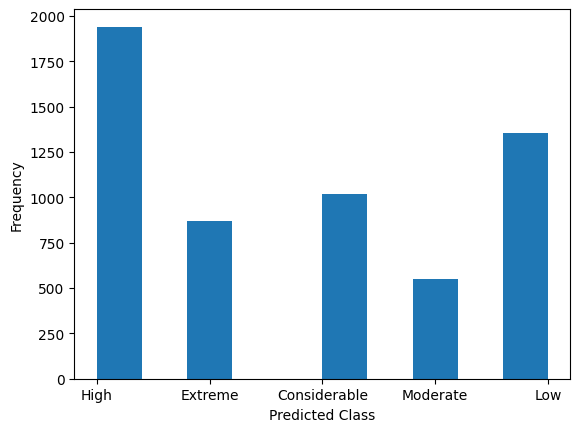

col_0,Considerable,Extreme,High,Low,Moderate
avalanche_occurred,,,,,
0,719,241,1026,1340,491
1,297,628,914,12,57


In [200]:
# ============================================
# PREDICTED RISK CLASSES
# ============================================
print("\n" + "="*70)
print("PREDICTED RISK CLASS")
print("="*70)

plt.hist(y_pred_risk_class)
plt.xlabel('Predicted Class')
plt.ylabel('Frequency')
plt.show()

#true avalanche crosstab by predicted class
pd.crosstab(y_test, y_pred_risk_class)

In [201]:
training_data['avalanche_size'].describe()

count    28623.000000
mean         0.556248
std          0.850648
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          5.000000
Name: avalanche_size, dtype: float64


FEATURE IMPORTANCE WITH SHAP

Generating SHAP explanations...

Creating SHAP summary plot...


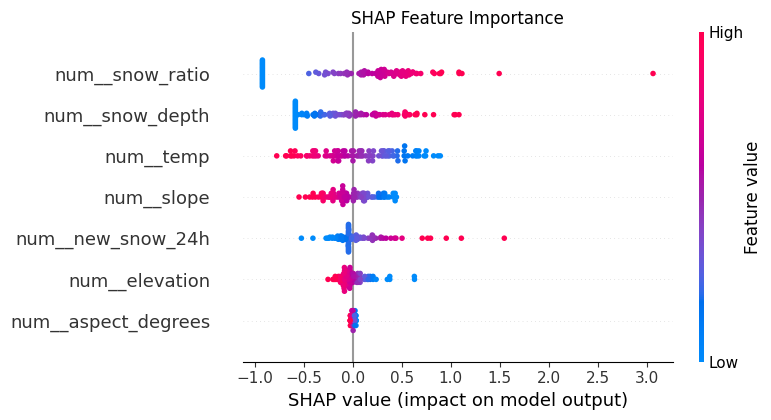

✅ SHAP summary plot saved as 'shap_summary.png'

Creating SHAP bar plot...


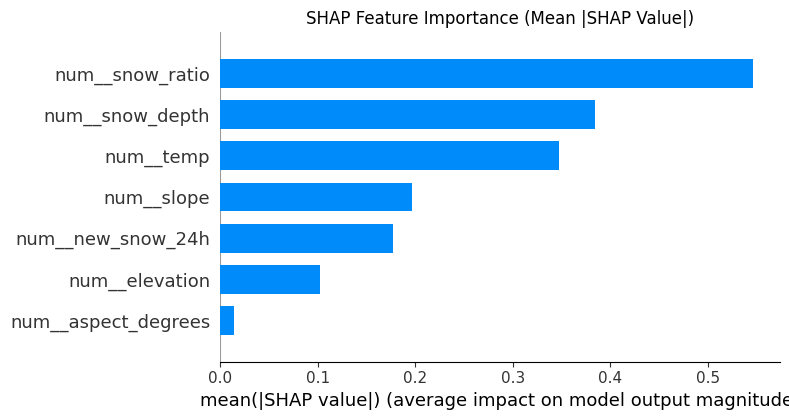

✅ SHAP bar plot saved as 'shap_bar.png'

Creating SHAP feature importance dataframe...

Top 15 features by SHAP importance:
            feature  shap_value
    num__snow_ratio    0.546439
    num__snow_depth    0.384282
          num__temp    0.347483
         num__slope    0.196949
  num__new_snow_24h    0.177670
     num__elevation    0.102863
num__aspect_degrees    0.014699

Creating SHAP waterfall plot for a sample prediction...


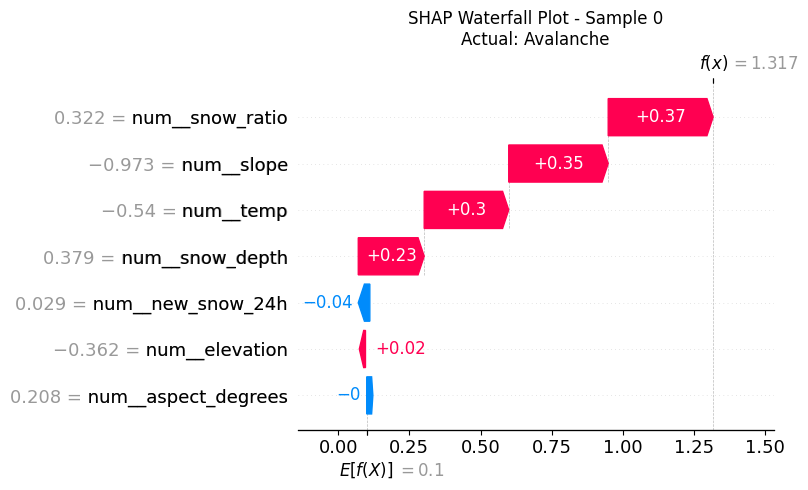

✅ SHAP waterfall plot saved as 'shap_waterfall.png'

Creating SHAP dependence plots for top features...


<Figure size 1000x600 with 0 Axes>

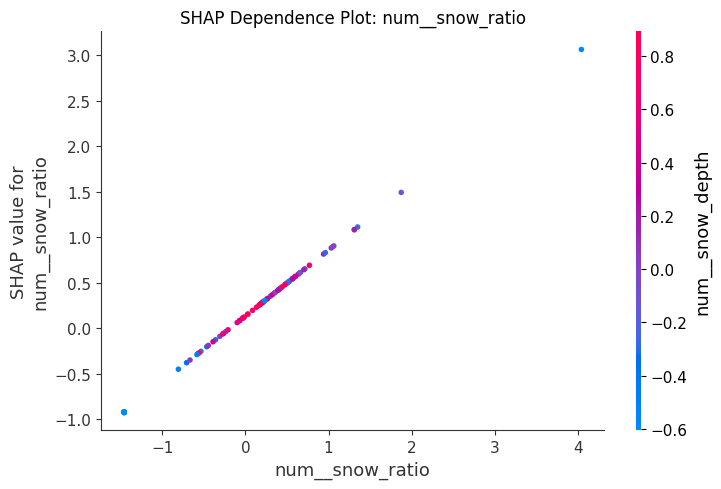

✅ Dependence plot for num__snow_ratio saved


<Figure size 1000x600 with 0 Axes>

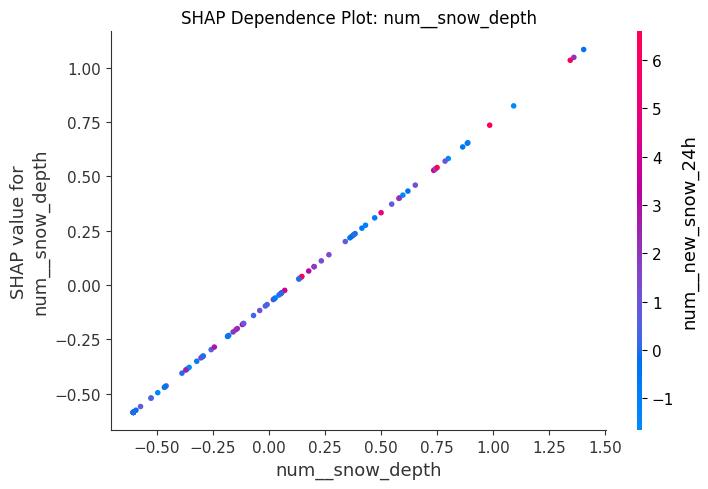

✅ Dependence plot for num__snow_depth saved


<Figure size 1000x600 with 0 Axes>

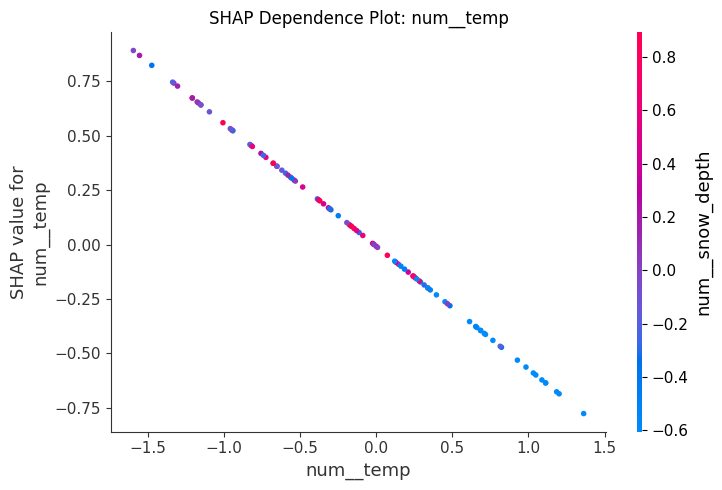

✅ Dependence plot for num__temp saved

Creating SHAP force plot for multiple predictions...


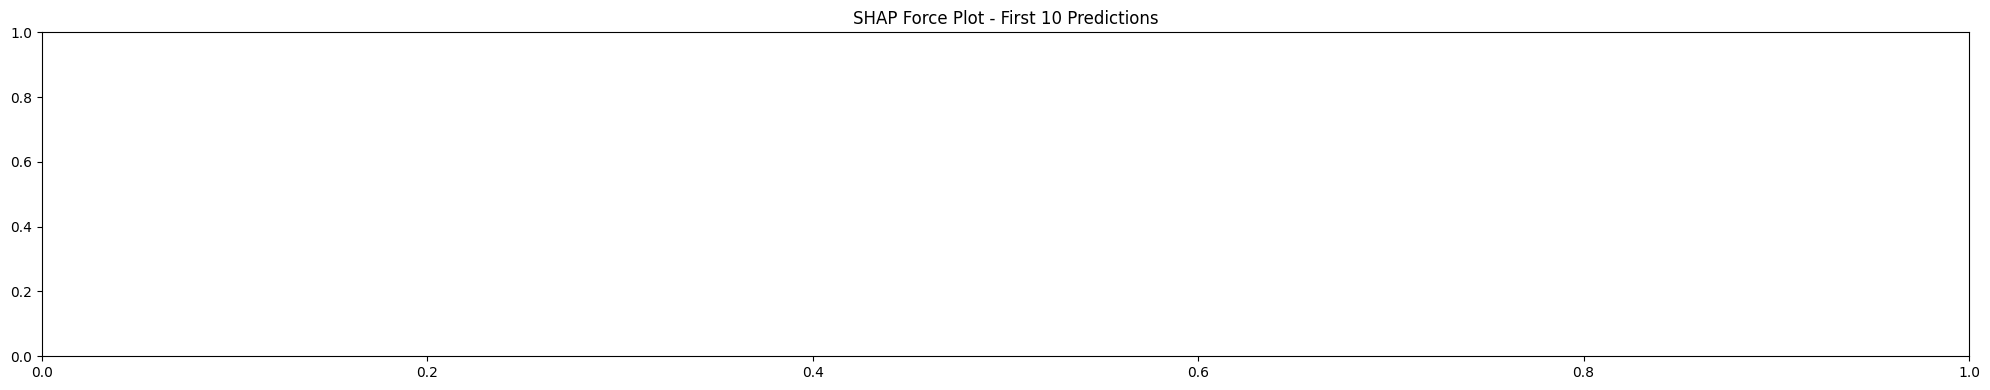

✅ SHAP force plot saved as 'shap_force.png'

Comparing SHAP with model coefficients...

Comparison of SHAP importance vs Coefficient magnitude:
            feature  coefficient  abs_coefficient  shap_importance
    num__snow_ratio     0.724536         0.724536         0.546439
    num__snow_depth     0.829997         0.829997         0.384282
          num__temp    -0.563794         0.563794         0.347483
         num__slope    -0.382089         0.382089         0.196949
  num__new_snow_24h     0.114448         0.114448         0.177670
     num__elevation    -0.143490         0.143490         0.102863
num__aspect_degrees    -0.028247         0.028247         0.014699


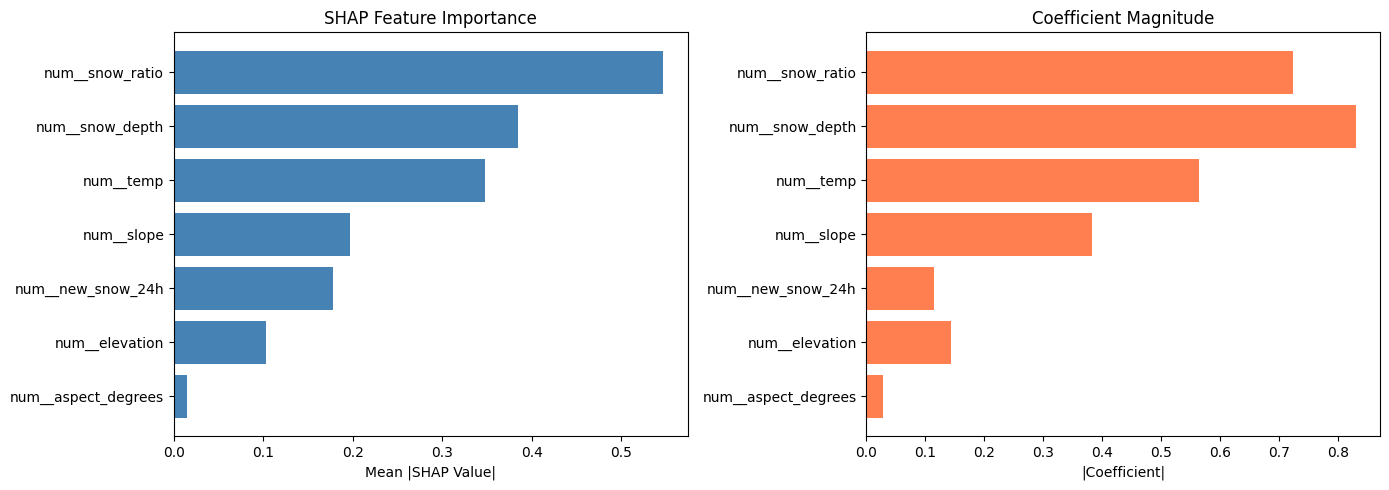

✅ Comparison plot saved as 'shap_vs_coef.png'

Saving SHAP analysis results...
✅ SHAP importance saved to 'shap_importance.csv'

EXPLAINABLE RESPONSE

explanation: 

     feature: num__snow_ratio
     shap_impact: 0.5464
     direction: increasing

     feature: num__snow_depth
     shap_impact: 0.3843
     direction: increasing

     feature: num__temp
     shap_impact: 0.3475
     direction: decreasing

     feature: num__slope
     shap_impact: 0.1969
     direction: decreasing

     feature: num__new_snow_24h
     shap_impact: 0.1777
     direction: increasing

     feature: num__elevation
     shap_impact: 0.1029
     direction: decreasing

     feature: num__aspect_degrees
     shap_impact: 0.0147
     direction: decreasing


In [202]:
# ============================================
# FEATURE IMPORTANCE WITH SHAP
# ============================================
print("\n" + "="*80)
print("FEATURE IMPORTANCE WITH SHAP")
print("="*80)

# Install shap if not already installed
try:
    import shap
except ImportError:
    print("Installing SHAP...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'shap'])
    import shap

# Create a function to explain predictions with SHAP
def explain_with_shap(model, X_train_sample, X_test_sample, feature_names, n_samples=100):
    """
    Generate SHAP explanations for logistic regression model
    """
    print("\nGenerating SHAP explanations...")
    
    # For sklearn pipeline, we need to extract the classifier and preprocessor
    if hasattr(model, 'named_steps'):
        # Get the preprocessor and classifier
        preprocessor = model.named_steps['preprocessor']
        classifier = model.named_steps['classifier']
        
        # Transform the data
        X_train_transformed = preprocessor.transform(X_train_sample)
        X_test_transformed = preprocessor.transform(X_test_sample)
        
        # Get feature names after preprocessing
        try:
            if hasattr(preprocessor, 'get_feature_names_out'):
                transformed_feature_names = preprocessor.get_feature_names_out()
            else:
                # Fallback: generate generic names
                transformed_feature_names = [f"feature_{i}" for i in range(X_train_transformed.shape[1])]
        except:
            transformed_feature_names = [f"feature_{i}" for i in range(X_train_transformed.shape[1])]
        
        # Create SHAP explainer for linear model
        if hasattr(classifier, 'coef_'):
            # For linear models, we can use LinearExplainer
            explainer = shap.LinearExplainer(classifier, X_train_transformed, feature_perturbation="interventional")
            shap_values = explainer.shap_values(X_test_transformed)
            
            return shap_values, X_test_transformed, transformed_feature_names, classifier
        else:
            # For tree-based models, use TreeExplainer
            explainer = shap.TreeExplainer(classifier)
            shap_values = explainer.shap_values(X_test_transformed)
            
            return shap_values, X_test_transformed, transformed_feature_names, classifier
    else:
        # Direct model (no pipeline)
        if hasattr(model, 'coef_'):
            explainer = shap.LinearExplainer(model, X_train_sample)
            shap_values = explainer.shap_values(X_test_sample)
            return shap_values, X_test_sample, feature_names, model
        else:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test_sample)
            return shap_values, X_test_sample, feature_names, model

# Take a sample of data for SHAP (to avoid memory issues)
n_shap_samples = min(100, len(X_test))
X_test_sample = X_test.iloc[:n_shap_samples] if hasattr(X_test, 'iloc') else X_test[:n_shap_samples]
X_train_sample = X_train.iloc[:min(200, len(X_train))] if hasattr(X_train, 'iloc') else X_train[:min(200, len(X_train))]

# Get SHAP values

shap_values, X_test_transformed, feature_names, classifier = explain_with_shap(
    best_pipeline, X_train_sample, X_test_sample, feature_cols
)
    
# ============================================
# 1. SUMMARY PLOT (Most Important)
# ============================================
print("\nCreating SHAP summary plot...")
plt.figure(figsize=(12, 8))
    
if isinstance(shap_values, list):
    # For multi-class, use the positive class (class 1)
    shap.summary_plot(shap_values[1], X_test_transformed, 
                     feature_names=feature_names, show=False)
    plt.title('SHAP Feature Importance (Class 1 - Avalanche)')
else:
    shap.summary_plot(shap_values, X_test_transformed, 
                     feature_names=feature_names, show=False)
    plt.title('SHAP Feature Importance')
    
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ SHAP summary plot saved as 'shap_summary.png'")
    
# ============================================
# 2. BAR PLOT (Global Feature Importance)
# ============================================
print("\nCreating SHAP bar plot...")
plt.figure(figsize=(10, 6))
    
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test_transformed, 
                        feature_names=feature_names, plot_type="bar", show=False)
else:
    shap.summary_plot(shap_values, X_test_transformed, 
                        feature_names=feature_names, plot_type="bar", show=False)
    
plt.title('SHAP Feature Importance (Mean |SHAP Value|)')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ SHAP bar plot saved as 'shap_bar.png'")
    
# ============================================
# 3. FEATURE IMPORTANCE DATAFRAME
# ============================================
print("\nCreating SHAP feature importance dataframe...")
    
if isinstance(shap_values, list):
    # For binary classification, use class 1
    shap_values_mean = np.abs(shap_values[1]).mean(axis=0)
else:
    shap_values_mean = np.abs(shap_values).mean(axis=0)
    
# Create dataframe
shap_importance = pd.DataFrame({
    'feature': feature_names[:len(shap_values_mean)],
    'shap_value': shap_values_mean
}).sort_values('shap_value', ascending=False)
    
print("\nTop 15 features by SHAP importance:")
print(shap_importance.head(15).to_string(index=False))
    
# ============================================
# 4. WATERFALL PLOT (Single Prediction)
# ============================================
print("\nCreating SHAP waterfall plot for a sample prediction...")
    
# Take first test sample
sample_idx = 0
if isinstance(shap_values, list):
    sample_shap = shap_values[1][sample_idx]
else:
    sample_shap = shap_values[sample_idx]
    
# Create waterfall plot
plt.figure(figsize=(12, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=sample_shap,
        base_values=classifier.intercept_[0] if hasattr(classifier, 'intercept_') else 0,
        data=X_test_transformed[sample_idx],
        feature_names=feature_names
    ),
    show=False,
    max_display=15
)
plt.title(f'SHAP Waterfall Plot - Sample {sample_idx}\n' + 
            f'Actual: {"Avalanche" if y_test.iloc[sample_idx] == 1 else "No Avalanche"}')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ SHAP waterfall plot saved as 'shap_waterfall.png'")
    
# ============================================
# 5. DEPENDENCE PLOTS (Top 3 Features)
# ============================================
print("\nCreating SHAP dependence plots for top features...")
    
top_features = shap_importance.head(3)['feature'].values
    
for i, feature in enumerate(top_features):
    try:
        # Find feature index
        if feature in feature_names:
            feature_idx = list(feature_names).index(feature)
                
            plt.figure(figsize=(10, 6))
                
            if isinstance(shap_values, list):
                shap.dependence_plot(
                    feature_idx, shap_values[1], X_test_transformed,
                    feature_names=feature_names, show=False
                )
            else:
                shap.dependence_plot(
                    feature_idx, shap_values, X_test_transformed,
                    feature_names=feature_names, show=False
                )
                
            plt.title(f'SHAP Dependence Plot: {feature}')
            plt.tight_layout()
            plt.savefig(f'shap_dependence_{feature}.png', dpi=300, bbox_inches='tight')
            plt.show()
            print(f"✅ Dependence plot for {feature} saved")
    except Exception as e:
        print(f"⚠️ Could not create dependence plot for {feature}: {e}")
    
# ============================================
# 6. FORCE PLOT (Multiple Predictions)
# ============================================
print("\nCreating SHAP force plot for multiple predictions...")
    
# Take first 10 test samples
n_force = min(10, len(X_test_transformed))
    
plt.figure(figsize=(20, 4))
    
if isinstance(shap_values, list):
    shap.force_plot(
        classifier.intercept_[0] if hasattr(classifier, 'intercept_') else 0,
        shap_values[1][:n_force],
        X_test_transformed[:n_force],
        feature_names=feature_names,
        matplotlib=False,
        show=True
    )
else:
    shap.force_plot(
        classifier.intercept_[0] if hasattr(classifier, 'intercept_') else 0,
        shap_values[:n_force],
        X_test_transformed[:n_force],
        feature_names=feature_names,
        matplotlib=False,
        show=True
    )
    
plt.title(f'SHAP Force Plot - First {n_force} Predictions')
plt.tight_layout()
plt.savefig('shap_force.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ SHAP force plot saved as 'shap_force.png'")
    
# ============================================
# 7. COMPARE WITH COEFFICIENTS (if available)
# ============================================
print("\nComparing SHAP with model coefficients...")
    
if hasattr(classifier, 'coef_'):
    coef = classifier.coef_[0] if len(classifier.coef_.shape) > 1 else classifier.coef_.flatten()
        
    comparison = pd.DataFrame({
        'feature': feature_names[:len(coef)],
        'coefficient': coef,
        'abs_coefficient': np.abs(coef),
        'shap_importance': shap_importance.set_index('feature').loc[feature_names[:len(coef)], 'shap_value'].values
    }).sort_values('shap_importance', ascending=False)
        
    print("\nComparison of SHAP importance vs Coefficient magnitude:")
    print(comparison.head(10).to_string(index=False))
        
    # Plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
    # SHAP importance
    top_shap = comparison.head(10)
    axes[0].barh(range(len(top_shap)), top_shap['shap_importance'], color='steelblue')
    axes[0].set_yticks(range(len(top_shap)))
    axes[0].set_yticklabels(top_shap['feature'])
    axes[0].set_xlabel('Mean |SHAP Value|')
    axes[0].set_title('SHAP Feature Importance')
    axes[0].invert_yaxis()
        
    # Coefficient magnitude
    axes[1].barh(range(len(top_shap)), top_shap['abs_coefficient'], color='coral')
    axes[1].set_yticks(range(len(top_shap)))
    axes[1].set_yticklabels(top_shap['feature'])
    axes[1].set_xlabel('|Coefficient|')
    axes[1].set_title('Coefficient Magnitude')
    axes[1].invert_yaxis()
        
    plt.tight_layout()
    plt.savefig('shap_vs_coef.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Comparison plot saved as 'shap_vs_coef.png'")
    
# ============================================
# 8. SAVE SHAP VALUES
# ============================================
print("\nSaving SHAP analysis results...")
    
# Save SHAP importance to CSV
shap_importance.to_csv('shap_importance.csv', index=False)
print("✅ SHAP importance saved to 'shap_importance.csv'")
    
# Update model data with SHAP information
if 'model_data' in locals():
    model_data['shap_importance'] = shap_importance.to_dict('records')
    model_data['top_features_shap'] = shap_importance.head(10)['feature'].tolist()
    
# ============================================
# 9. EXPLAINABLE RESPONSE
# ============================================
print("\n" + "="*80)
print("EXPLAINABLE RESPONSE")
print("="*80)
    
print("\nexplanation: ")
for i, row in shap_importance.head(7).iterrows():
    print(f"\n     feature: {row['feature']}")
    print(f"     shap_impact: {row['shap_value']:.4f}")
        
    # Try to get direction of impact
    if hasattr(classifier, 'coef_') and row['feature'] in feature_names[:len(coef)]:
        idx = list(feature_names).index(row['feature'])
        coef_val = coef[idx]
        if coef_val > 0:
            print(f"     direction: increasing")
        else:
            print(f"     direction: decreasing")


In [203]:
#sample location
X_test.iloc[2721]

Observation ID                                 NEG_003072
Date                            2022-03-21 07:00:00+00:00
Longitude                                       -106.5133
latitude                                          39.0222
Area                                              Sawatch
Aspect                                                NaN
Type                                                  NaN
Trigger                                               NaN
avalanche_size                                        0.0
elevation                                          3954.0
slope                                                30.0
aspect_degrees                                      128.6
aspect_cardinal                                        NW
snow_depth                                          109.2
new_snow_24h                                         -2.3
swe                                                  26.7
temp                                                -14.0
wind_speed    

In [204]:
#sample avalanche probability
y_pred_proba[2721]

array([0.34935296, 0.65064704])


EXAMINING MODEL PREDICTIONS
--------------------------------------------------
Confusion Matrix:
[[2131 1686]
 [ 151 1757]]
True Negatives:  2131
False Positives: 1686
False Negatives: 151
True Positives:  1757

Accuracy:  0.6791
Recall:    0.9209
Precision: 0.5103

CHECK PREDICTION PROBABILITIES
--------------------------------------------------
Probability stats for positive class:
  Min: 0.0459
  Max: 0.9999
  Mean: 0.5194
  Std: 0.2704
  Extreme probabilities (<0.05 or >0.95): 0.8%


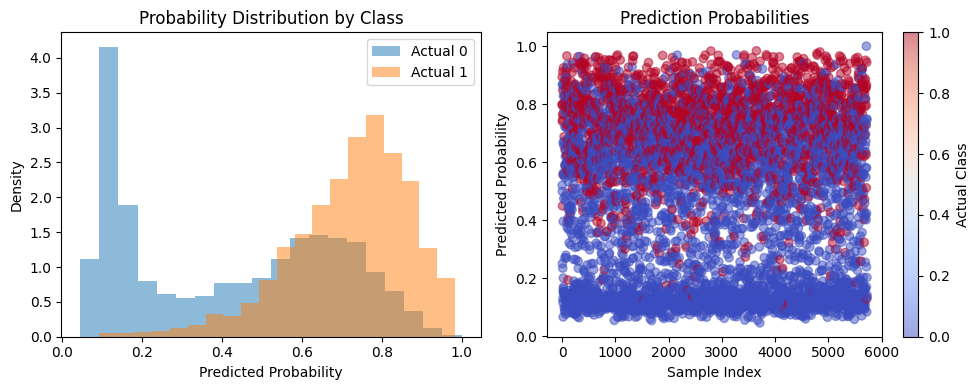

In [205]:
# EXAMINE MODEL PREDICTIONS
print("\nEXAMINING MODEL PREDICTIONS")
print("-" * 50)

# Get predictions
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

if len(cm) == 2:
    tn, fp, fn, tp = cm.ravel()
    print(f"True Negatives:  {tn}")
    print(f"False Positives: {fp}")
    print(f"False Negatives: {fn}")
    print(f"True Positives:  {tp}")
    
    # Calculate metrics
    accuracy = (tn + tp) / (tn + fp + fn + tp)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    print(f"\nAccuracy:  {accuracy:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {precision:.4f}")

# CHECK PREDICTION PROBABILITIES
print("\nCHECK PREDICTION PROBABILITIES")
print("-" * 50)

if len(np.unique(y)) == 2:
    # Look at probabilities for positive class
    pos_probs = y_proba[:, 1]
    print(f"Probability stats for positive class:")
    print(f"  Min: {pos_probs.min():.4f}")
    print(f"  Max: {pos_probs.max():.4f}")
    print(f"  Mean: {pos_probs.mean():.4f}")
    print(f"  Std: {pos_probs.std():.4f}")
    
    # Check if probabilities are extreme (near 0 or 1)
    extreme_probs = ((pos_probs < 0.05) | (pos_probs > 0.95)).mean()
    print(f"  Extreme probabilities (<0.05 or >0.95): {extreme_probs:.1%}")
    
    # Plot probability distribution
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.hist(pos_probs[y_test == 0], bins=20, alpha=0.5, label='Actual 0', density=True)
    plt.hist(pos_probs[y_test == 1], bins=20, alpha=0.5, label='Actual 1', density=True)
    plt.xlabel('Predicted Probability')
    plt.ylabel('Density')
    plt.title('Probability Distribution by Class')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.scatter(range(len(pos_probs)), pos_probs, c=y_test, alpha=0.5, cmap='coolwarm')
    plt.xlabel('Sample Index')
    plt.ylabel('Predicted Probability')
    plt.title('Prediction Probabilities')
    plt.colorbar(label='Actual Class')
    
    plt.tight_layout()
    plt.show()